In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Sales_analysis/train.csv")

In [6]:
df.head()
df.shape

(9800, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [9]:
df.isnull().sum().sort_values(ascending = False)

Postal Code      11
Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Ship Date         0
Customer Name     0
Segment           0
Country           0
Customer ID       0
City              0
State             0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df = df.dropna(subset=['Postal Code'])

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)


In [36]:
# Total sales
df['Sales'].sum()

np.float64(2252607.4127)

In [37]:
# Sale by Region
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [38]:
# Sale by Category
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

In [39]:
# Sale by Segment
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

Segment
Consumer       1.146708e+06
Corporate      6.822118e+05
Home Office    4.236874e+05
Name: Sales, dtype: float64

In [41]:
# Region with highest Sales
df.groupby('Region')['Sales'].sum()

Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

In [35]:
# average sales per region
df.groupby('Region')['Sales'].mean().sort_values(ascending=False)

Region
South      243.524067
East       238.136033
West       226.184613
Central    216.357889
Name: Sales, dtype: float64

In [42]:
# number of unique orders per region
df.groupby('Region')['Order ID'].nunique()

Region
Central    1156
East       1363
South       810
West       1587
Name: Order ID, dtype: int64

In [33]:
# Highest revenue category
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

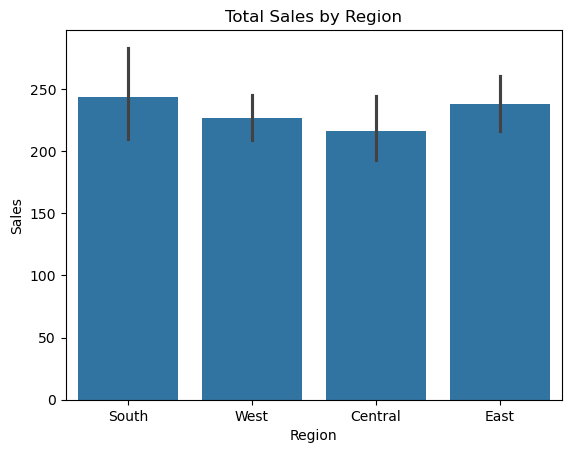

In [26]:
# Total Sales by Region
sns.barplot(x='Region', y='Sales', data=df)
plt.title("Total Sales by Region")
plt.show()

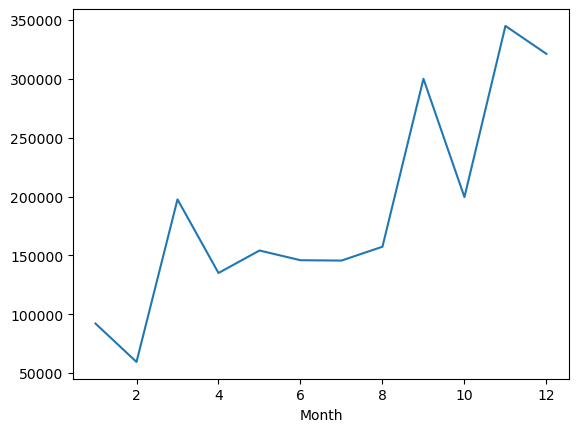

In [40]:
#Monthly Sales Trend
df['Month'] = df['Order Date'].dt.month
df.groupby('Month')['Sales'].sum().plot()
plt.show()

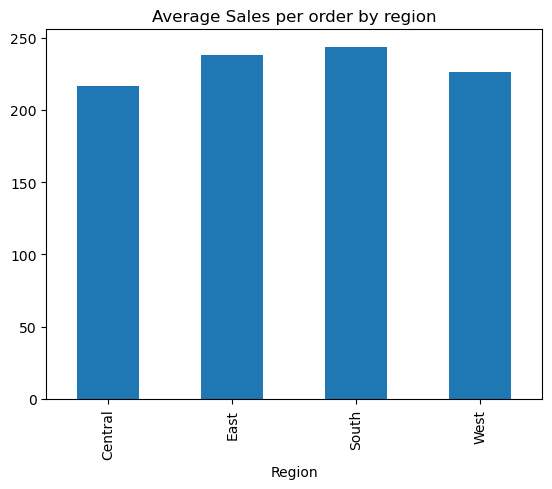

In [32]:
#Average sales by region
df.groupby('Region')['Sales'].mean().plot(kind='bar')
plt.title("Average Sales per order by region")
plt.show()

Key Business Insights

1️⃣ West region generates highest total revenue due to highest order volume.

2️⃣ South region has highest average sales per order, but lowest order count.

3️⃣ Technology category drives maximum revenue across the company.

4️⃣ Central region underperforms in both total sales and average order value.

5️⃣ Business implication:

Increase order frequency in South.

Improve marketing strategy in Central.

Focus on Technology upselling.